In [1]:
"""
IMPROVED PLSR MODEL WITH VALIDATION SET
Includes proper train/val/test split and component selection
"""

import pandas as pd
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================================
# FIND OPTIMAL COMPONENTS USING VALIDATION SET
# ============================================================================

def find_optimal_components_validation(X_train, y_train, X_val, y_val, max_components=20):
    """
    Use validation set to find optimal number of PLS components
    """
    print("\n" + "="*80)
    print("FINDING OPTIMAL COMPONENTS (Using Validation Set)")
    print("="*80)
    
    # Scale data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Try different numbers of components
    max_comp = min(max_components, X_train.shape[1], X_train.shape[0])
    n_components_range = range(1, max_comp + 1)
    
    train_scores = []
    val_scores = []
    
    print("\nTesting components...")
    print(f"{'Components':<12} {'Train RMSE':<12} {'Val RMSE':<12} {'Gap':<12}")
    print("-" * 60)
    
    for n_comp in n_components_range:
        plsr = PLSRegression(n_components=n_comp, scale=False)
        plsr.fit(X_train_scaled, y_train)
        
        # Train score
        y_train_pred = plsr.predict(X_train_scaled).flatten()
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        
        # Validation score
        y_val_pred = plsr.predict(X_val_scaled).flatten()
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        
        train_scores.append(train_rmse)
        val_scores.append(val_rmse)
        
        gap = val_rmse - train_rmse
        print(f"{n_comp:<12} {train_rmse:<12.4f} {val_rmse:<12.4f} {gap:<12.4f}")
    
    # Find optimal (minimum validation RMSE)
    optimal_idx = np.argmin(val_scores)
    optimal_n = list(n_components_range)[optimal_idx]
    optimal_val_rmse = min(val_scores)
    
    print("\n" + "-"*60)
    print(f"Optimal Components: {optimal_n}")
    print(f"Validation RMSE: {optimal_val_rmse:.4f}")
    print("-"*60)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: RMSE curves
    ax1 = axes[0]
    ax1.plot(list(n_components_range), train_scores, 'bo-', linewidth=2, 
             markersize=8, label='Train RMSE')
    ax1.plot(list(n_components_range), val_scores, 'ro-', linewidth=2, 
             markersize=8, label='Val RMSE')
    ax1.axvline(optimal_n, color='green', linestyle='--', linewidth=2, 
                label=f'Optimal: {optimal_n} components')
    ax1.set_xlabel('Number of Components', fontsize=12)
    ax1.set_ylabel('RMSE', fontsize=12)
    ax1.set_title('PLSR: Train vs Validation RMSE', fontsize=14, fontweight='bold')
    ax1.grid(alpha=0.3)
    ax1.legend()
    
    # Plot 2: Overfitting gap
    ax2 = axes[1]
    gaps = np.array(val_scores) - np.array(train_scores)
    ax2.plot(list(n_components_range), gaps, 'go-', linewidth=2, markersize=8)
    ax2.axhline(0, color='red', linestyle='--', linewidth=1)
    ax2.axvline(optimal_n, color='orange', linestyle='--', linewidth=2,
                label=f'Optimal: {optimal_n}')
    ax2.set_xlabel('Number of Components', fontsize=12)
    ax2.set_ylabel('Val RMSE - Train RMSE (Gap)', fontsize=12)
    ax2.set_title('PLSR: Overfitting Gap Analysis', fontsize=14, fontweight='bold')
    ax2.grid(alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('plsr_component_selection_validation.png', dpi=300)
    print("\n✓ Saved plot: plsr_component_selection_validation.png")
    
    return optimal_n, train_scores, val_scores

In [3]:
# ============================================================================
# IMPROVED PLSR TRAINING
# ============================================================================

def train_plsr_model_improved(X_train, y_train, X_val, y_val, X_test, y_test, 
                              n_components=10):
    """
    Train PLSR model with proper train/val/test evaluation
    """
    print("\n" + "="*80)
    print("TRAINING PLSR MODEL")
    print("="*80)
    
    # Scale features
    print("\nScaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Initialize PLSR
    print(f"\nTraining PLSR with {n_components} components...")
    plsr_model = PLSRegression(
        n_components=n_components,
        scale=False,
        max_iter=500
    )
    
    # Train
    start_time = time.time()
    plsr_model.fit(X_train_scaled, y_train)
    training_time = time.time() - start_time
    print(f"✓ Training completed in {training_time:.4f} seconds")
    
    # Predict on all sets
    print("\nMaking predictions...")
    y_train_pred = plsr_model.predict(X_train_scaled).flatten()
    y_val_pred = plsr_model.predict(X_val_scaled).flatten()
    y_test_pred = plsr_model.predict(X_test_scaled).flatten()
    
    # Evaluate
    print("\n" + "-"*60)
    print("PERFORMANCE METRICS")
    print("-"*60)
    
    # Helper function
    def calc_metrics(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        return rmse, mae, r2
    
    # Training metrics
    train_rmse, train_mae, train_r2 = calc_metrics(y_train, y_train_pred)
    print("\nTraining Set:")
    print(f"  RMSE: {train_rmse:.4f}")
    print(f"  MAE:  {train_mae:.4f}")
    print(f"  R²:   {train_r2:.4f}")
    
    # Validation metrics
    val_rmse, val_mae, val_r2 = calc_metrics(y_val, y_val_pred)
    print("\nValidation Set:")
    print(f"  RMSE: {val_rmse:.4f}")
    print(f"  MAE:  {val_mae:.4f}")
    print(f"  R²:   {val_r2:.4f}")
    
    # Test metrics
    test_rmse, test_mae, test_r2 = calc_metrics(y_test, y_test_pred)
    print("\nTest Set:")
    print(f"  RMSE: {test_rmse:.4f}")
    print(f"  MAE:  {test_mae:.4f}")
    print(f"  R²:   {test_r2:.4f}")
    
    # Overfitting analysis
    print("\nOverfitting Analysis:")
    print(f"  Train-Val R² Gap:  {train_r2 - val_r2:.4f}")
    print(f"  Train-Test R² Gap: {train_r2 - test_r2:.4f}")
    print(f"  Val-Test R² Gap:   {val_r2 - test_r2:.4f}")
    
    # Model info
    print(f"\nModel Info:")
    print(f"  Components: {n_components}")
    print(f"  Training Time: {training_time:.4f}s")
    
    try:
        explained_var = plsr_model.x_scores_.var(axis=0).sum() / X_train_scaled.var(axis=0).sum()
        print(f"  Explained Variance (X): {explained_var:.3f}")
    except:
        print(f"  Explained Variance: N/A")
    
    # Visualization
    create_plsr_visualizations(y_train, y_train_pred, y_val, y_val_pred, 
                              y_test, y_test_pred, n_components)
    
    return plsr_model, scaler, {
        'train_rmse': train_rmse, 'train_mae': train_mae, 'train_r2': train_r2,
        'val_rmse': val_rmse, 'val_mae': val_mae, 'val_r2': val_r2,
        'test_rmse': test_rmse, 'test_mae': test_mae, 'test_r2': test_r2,
        'training_time': training_time
    }

In [4]:
# ============================================================================
# VISUALIZATION
# ============================================================================

def create_plsr_visualizations(y_train, y_train_pred, y_val, y_val_pred, 
                               y_test, y_test_pred, n_components):
    """Create comprehensive visualizations"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Train predictions
    ax1 = axes[0, 0]
    ax1.scatter(y_train, y_train_pred, alpha=0.5, s=10)
    ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', linewidth=2)
    ax1.set_xlabel('Actual FI')
    ax1.set_ylabel('Predicted FI')
    ax1.set_title('Training Set: Predictions vs Actual', fontweight='bold')
    ax1.grid(alpha=0.3)
    train_r2 = r2_score(y_train, y_train_pred)
    ax1.text(0.05, 0.95, f'R² = {train_r2:.4f}', transform=ax1.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
    
    # 2. Val predictions
    ax2 = axes[0, 1]
    ax2.scatter(y_val, y_val_pred, alpha=0.5, s=10, color='orange')
    ax2.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
             'r--', linewidth=2)
    ax2.set_xlabel('Actual FI')
    ax2.set_ylabel('Predicted FI')
    ax2.set_title('Validation Set: Predictions vs Actual', fontweight='bold')
    ax2.grid(alpha=0.3)
    val_r2 = r2_score(y_val, y_val_pred)
    ax2.text(0.05, 0.95, f'R² = {val_r2:.4f}', transform=ax2.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
    
    # 3. Test predictions
    ax3 = axes[0, 2]
    ax3.scatter(y_test, y_test_pred, alpha=0.5, s=10, color='green')
    ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2)
    ax3.set_xlabel('Actual FI')
    ax3.set_ylabel('Predicted FI')
    ax3.set_title('Test Set: Predictions vs Actual', fontweight='bold')
    ax3.grid(alpha=0.3)
    test_r2 = r2_score(y_test, y_test_pred)
    ax3.text(0.05, 0.95, f'R² = {test_r2:.4f}', transform=ax3.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
    
    # 4. Residuals - Train
    ax4 = axes[1, 0]
    residuals_train = y_train - y_train_pred
    ax4.hist(residuals_train, bins=50, edgecolor='black', alpha=0.7)
    ax4.axvline(0, color='red', linestyle='--', linewidth=2)
    ax4.set_xlabel('Residual')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Training Residuals', fontweight='bold')
    ax4.grid(alpha=0.3)
    
    # 5. Residuals - Val
    ax5 = axes[1, 1]
    residuals_val = y_val - y_val_pred
    ax5.hist(residuals_val, bins=50, edgecolor='black', alpha=0.7, color='orange')
    ax5.axvline(0, color='red', linestyle='--', linewidth=2)
    ax5.set_xlabel('Residual')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Validation Residuals', fontweight='bold')
    ax5.grid(alpha=0.3)
    
    # 6. R² Comparison
    ax6 = axes[1, 2]
    r2_scores = [train_r2, val_r2, test_r2]
    sets = ['Train', 'Val', 'Test']
    colors = ['steelblue', 'orange', 'green']
    bars = ax6.bar(sets, r2_scores, color=colors, edgecolor='black', alpha=0.8)
    ax6.set_ylabel('R² Score')
    ax6.set_title(f'R² Comparison (n_components={n_components})', fontweight='bold')
    ax6.set_ylim([0, max(r2_scores) * 1.2])
    ax6.grid(alpha=0.3, axis='y')
    for bar, score in zip(bars, r2_scores):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('plsr_performance_validation.png', dpi=300)
    print("\n✓ Saved visualization: plsr_performance_validation.png")

In [5]:
# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

def analyze_plsr_features(plsr_model, feature_names, n_top=14):
    """Analyze feature importance"""
    
    print("\n" + "="*80)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*80)
    
    coefficients = np.abs(plsr_model.coef_.flatten())
    
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': coefficients
    }).sort_values('importance', ascending=False)
    
    print(f"\nAll Features (sorted by importance):")
    print(feature_importance.to_string(index=False))
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(feature_importance)), feature_importance['importance'], 
             color='steelblue', edgecolor='black')
    plt.yticks(range(len(feature_importance)), feature_importance['feature'])
    plt.xlabel('Absolute Coefficient', fontsize=12)
    plt.title('PLSR: Feature Importances', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('plsr_feature_importance_validation.png', dpi=300)
    print("\n✓ Saved plot: plsr_feature_importance_validation.png")
    
    return feature_importance

IMPROVED PLSR MODEL WITH VALIDATION SET

1. LOADING DATA (Train/Val/Test)
------------------------------------------------------------
X_train shape: (11397, 19)
X_val shape: (3397, 19)
X_test shape: (8248, 19)
y_train shape: (11397,)
y_val shape: (3397,)
y_test shape: (8248,)

2. FINDING OPTIMAL COMPONENTS
------------------------------------------------------------

FINDING OPTIMAL COMPONENTS (Using Validation Set)

Testing components...
Components   Train RMSE   Val RMSE     Gap         
------------------------------------------------------------
1            0.0440       0.0422       -0.0018     
2            0.0407       0.0399       -0.0007     
3            0.0403       0.0409       0.0006      
4            0.0401       0.0408       0.0007      
5            0.0400       0.0410       0.0011      
6            0.0399       0.0412       0.0012      
7            0.0399       0.0413       0.0014      
8            0.0399       0.0414       0.0015      
9            0.0399       0

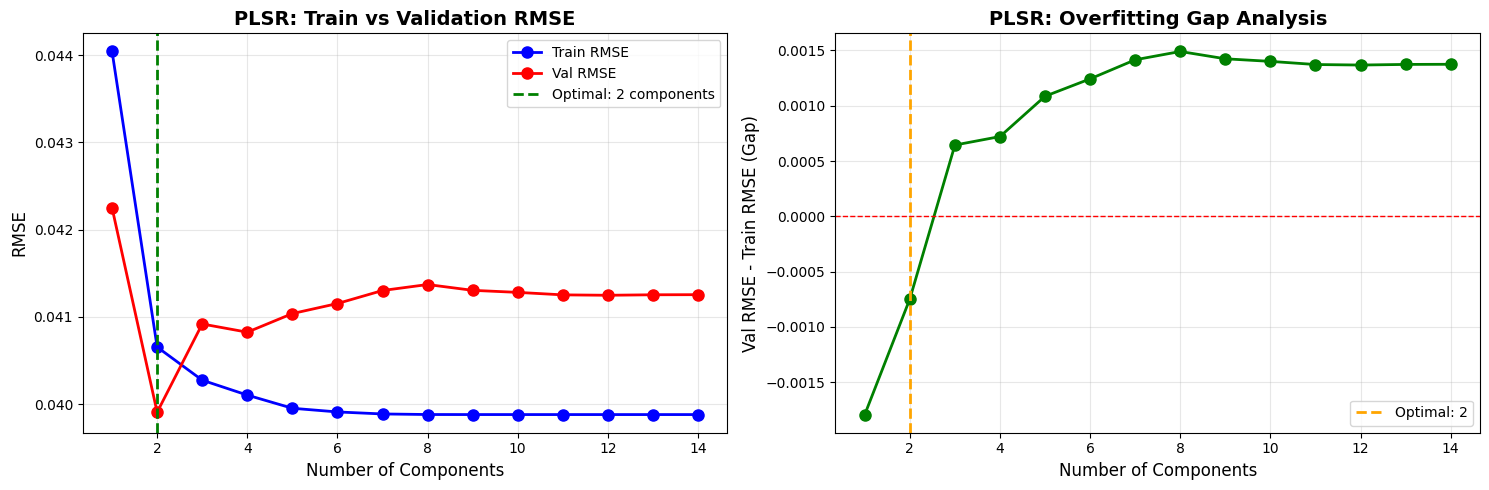

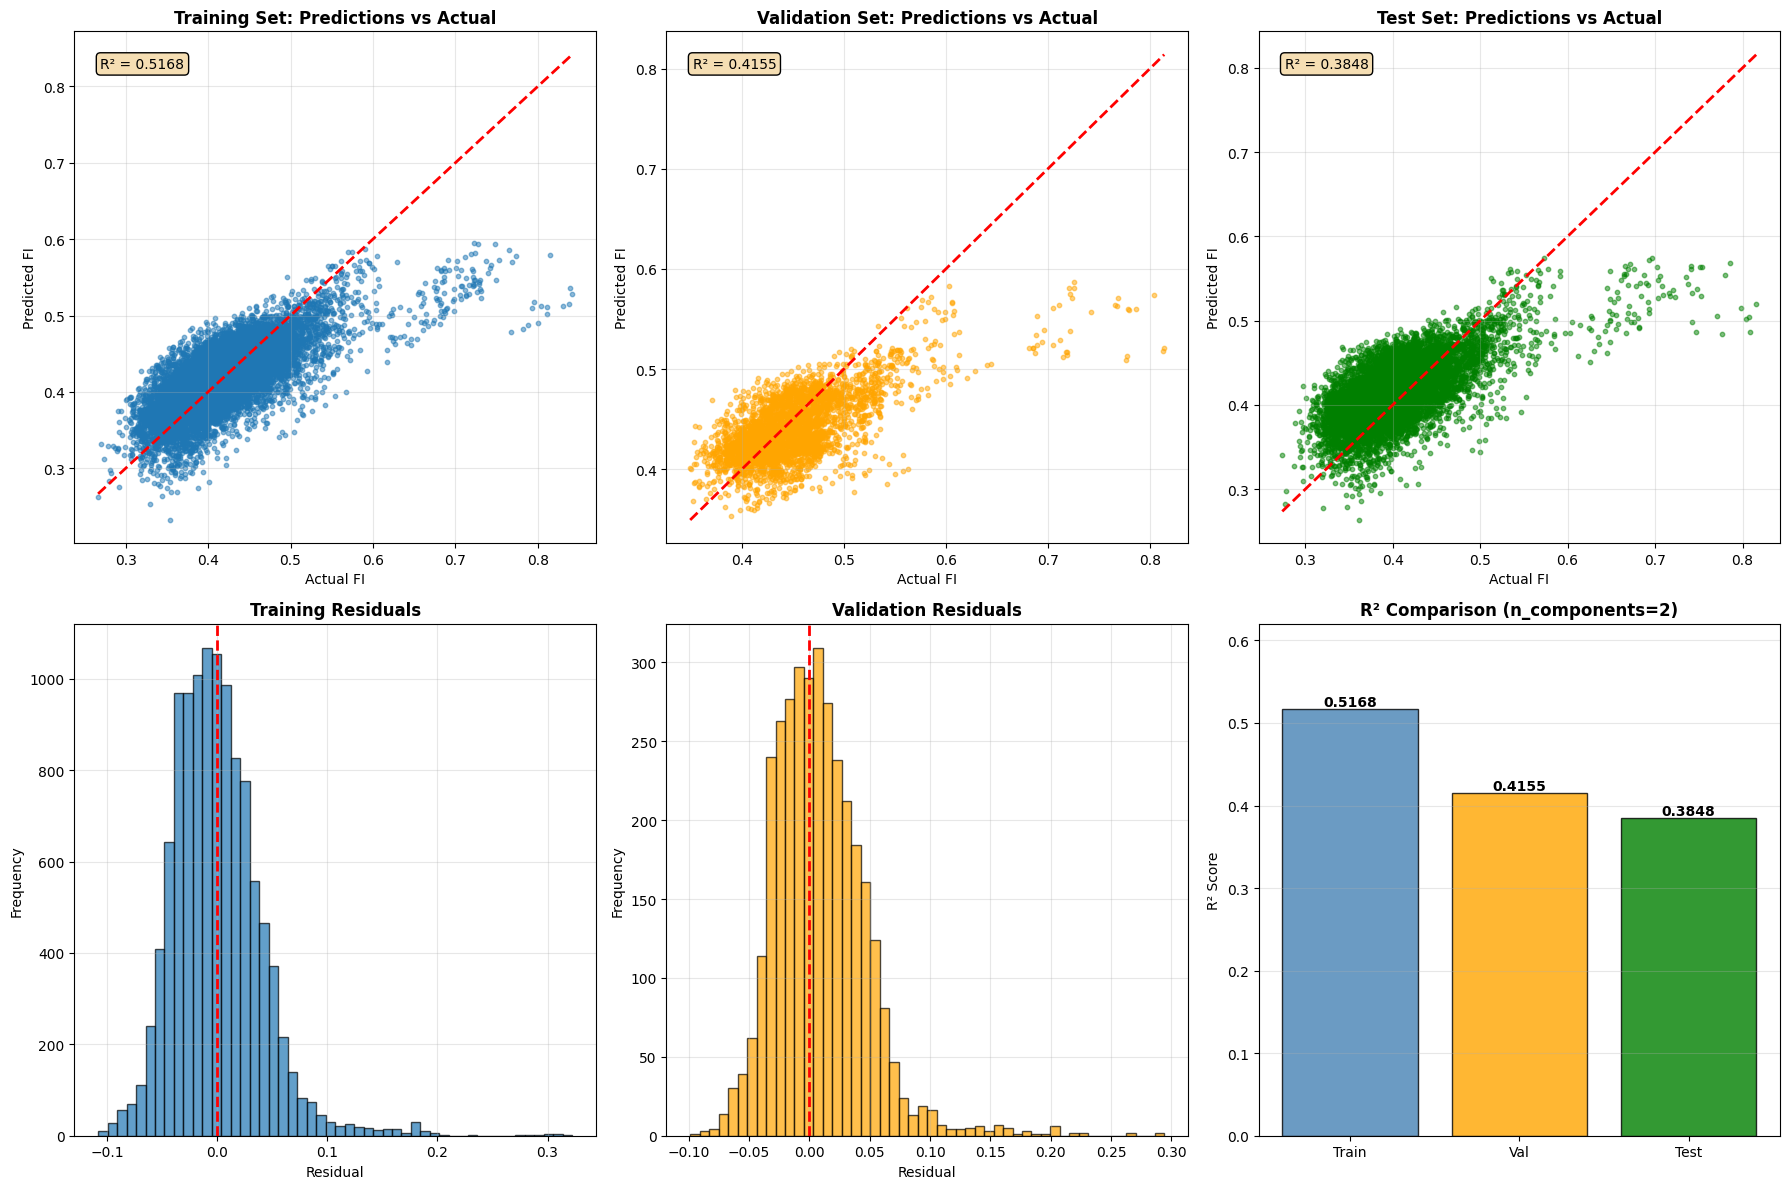

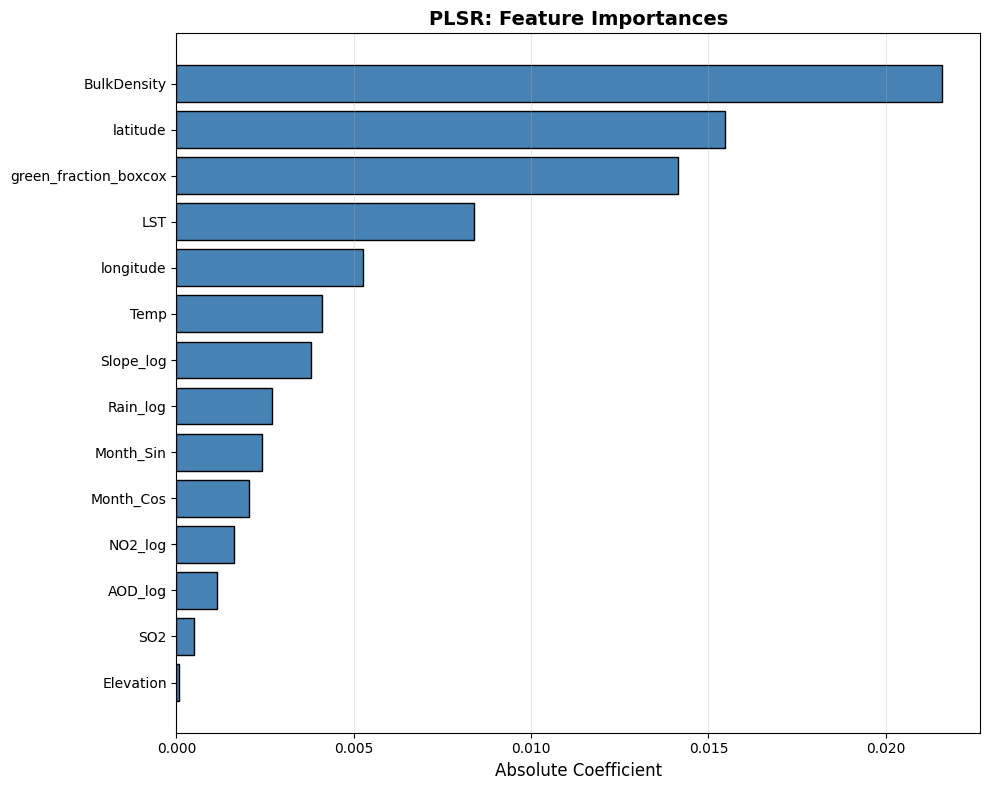

In [6]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    
    print("="*80)
    print("IMPROVED PLSR MODEL WITH VALIDATION SET")
    print("="*80)
    
    # Load data
    print("\n1. LOADING DATA (Train/Val/Test)")
    print("-" * 60)
    
    X_train = pd.read_csv('csv/X_train.csv')
    X_val = pd.read_csv('csv/X_val.csv')
    X_test = pd.read_csv('csv/X_test.csv')
    y_train = pd.read_csv('csv/y_train.csv').iloc[:, 0].values
    y_val = pd.read_csv('csv/y_val.csv').iloc[:, 0].values
    y_test = pd.read_csv('csv/y_test.csv').iloc[:, 0].values
    
    print(f"X_train shape: {X_train.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_val shape: {y_val.shape}")
    print(f"y_test shape: {y_test.shape}")
    
    # Features
    features_to_use = [
        'Rain_log', 'Temp', 'LST',
        'green_fraction_boxcox',
        'BulkDensity',
        'Elevation', 'Slope_log',
        'AOD_log', 'NO2_log', 'SO2',
        'Month_Sin', 'Month_Cos',
        'longitude', 'latitude'
    ]
    
    X_train_clean = X_train[features_to_use]
    X_val_clean = X_val[features_to_use]
    X_test_clean = X_test[features_to_use]
    
    # Find optimal components using validation set
    print("\n2. FINDING OPTIMAL COMPONENTS")
    print("-" * 60)
    
    optimal_n, train_scores, val_scores = find_optimal_components_validation(
        X_train_clean, y_train, X_val_clean, y_val, max_components=14
    )
    
    # Train with optimal components
    print("\n3. TRAINING WITH OPTIMAL COMPONENTS")
    print("-" * 60)
    
    plsr_model, scaler, metrics = train_plsr_model_improved(
        X_train_clean, y_train,
        X_val_clean, y_val,
        X_test_clean, y_test,
        n_components=optimal_n
    )
    
    # Feature importance
    print("\n4. FEATURE IMPORTANCE")
    print("-" * 60)
    
    feature_importance = analyze_plsr_features(plsr_model, features_to_use)
    
    # Save model
    print("\n5. SAVING MODEL")
    print("-" * 60)
    
    model_data = {
        'model': plsr_model,
        'scaler': scaler,
        'n_components': optimal_n,
        'features': features_to_use,
        'metrics': metrics,
        'feature_importance': feature_importance
    }
    
    with open('plsr_model_improved.pkl', 'wb') as f:
        pickle.dump(model_data, f)
    
    print("✓ Model saved to plsr_model_improved.pkl")
    
    # Summary
    print("\n" + "="*80)
    print("✅ IMPROVED PLSR MODEL COMPLETE")
    print("="*80)
    print(f"\n📊 FINAL RESULTS:")
    print(f"  Optimal Components: {optimal_n}")
    print(f"  Train R²: {metrics['train_r2']:.4f}")
    print(f"  Val R²:   {metrics['val_r2']:.4f}")
    print(f"  Test R²:  {metrics['test_r2']:.4f}")
    print(f"  Test RMSE: {metrics['test_rmse']:.4f}")
    print(f"  Test MAE:  {metrics['test_mae']:.4f}")
    print("\n📁 Files created:")
    print("  - plsr_model_improved.pkl")
    print("  - plsr_component_selection_validation.png")
    print("  - plsr_performance_validation.png")
    print("  - plsr_feature_importance_validation.png")
    print("\n" + "="*80)